In [ ]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU()
            )

        self.enc1 = conv_block(3, 32)
        self.enc2 = conv_block(32, 64)
        self.enc3 = conv_block(64, 128)
        self.enc4 = conv_block(128, 256)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = conv_block(256, 512)

        self.up4 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec4 = conv_block(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec3 = conv_block(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec2 = conv_block(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.dec1 = conv_block(64, 32)

        self.final = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return torch.sigmoid(self.final(d1))

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate the UNet model using the definition from cell 3RXGSvAW9oRe
model = UNet().to(device)

# Define the path to your .pth file
model_path = '/content/sample_data/unet_coco.pth'

# Load the state dictionary
model.load_state_dict(torch.load(model_path, map_location=device))

# Set the model to evaluation mode
model.eval()

print("Model loaded successfully and set to evaluation mode.")

Model loaded successfully and set to evaluation mode.


In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

Saving 000000000108.jpg to 000000000108 (2).jpg


(np.float64(-0.5), np.float64(639.5), np.float64(426.5), np.float64(-0.5))

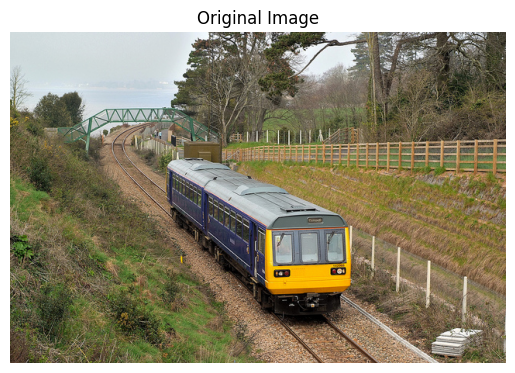

In [ ]:
import io
from google.colab import files

uploaded = files.upload()

# Get the filename of the uploaded image
filename = next(iter(uploaded))


image = Image.open(io.BytesIO(uploaded[filename])).convert("RGB")
image_np = np.array(image)

plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")

In [ ]:
print("Step 1: Decoded Image Shape:", image_np.shape)


Step 1: Decoded Image Shape: (427, 640, 3)


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

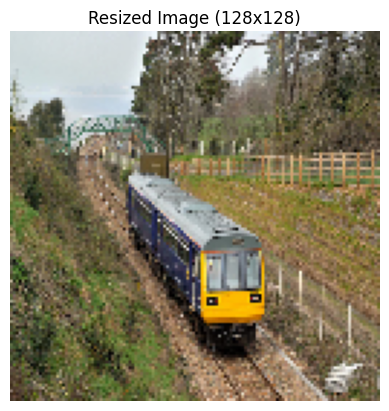

In [ ]:
resized = cv2.resize(image_np, (128, 128))

plt.imshow(resized)
plt.title("Resized Image (128x128)")
plt.axis("off")

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

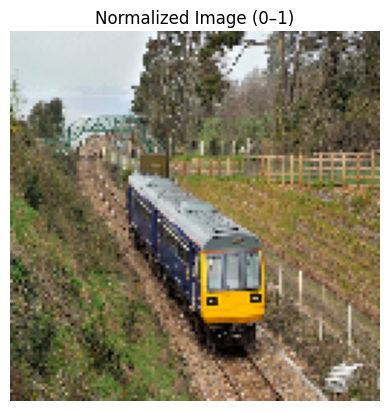

In [ ]:
normalized = resized / 255.0

plt.imshow(normalized)
plt.title("Normalized Image (0–1)")
plt.axis("off")

In [ ]:
input_tensor = torch.tensor(normalized).permute(2,0,1).unsqueeze(0).float().to(device)

print("Tensor Shape:", input_tensor.shape)

Tensor Shape: torch.Size([1, 3, 128, 128])


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

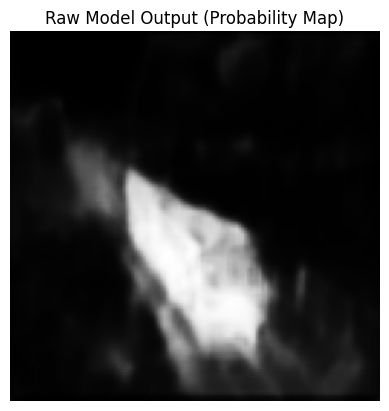

In [ ]:
model.eval()

with torch.no_grad():
    pred = model(input_tensor)

pred = pred.squeeze().cpu().numpy()

plt.imshow(pred, cmap='gray')
plt.title("Raw Model Output (Probability Map)")
plt.axis("off")

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

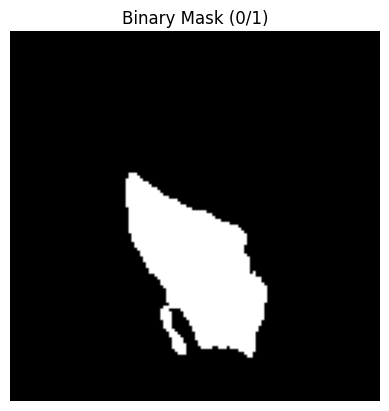

In [ ]:
binary_mask = (pred > 0.5).astype(np.uint8)

plt.imshow(binary_mask, cmap='gray')
plt.title("Binary Mask (0/1)")
plt.axis("off")

(np.float64(-0.5), np.float64(639.5), np.float64(426.5), np.float64(-0.5))

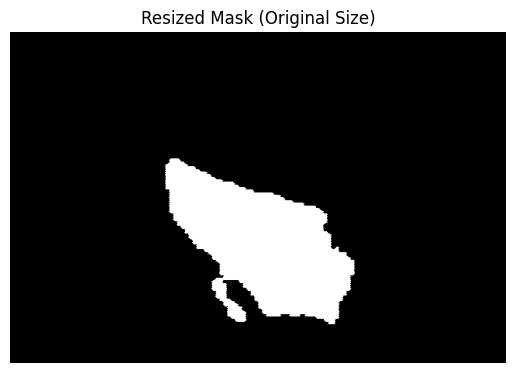

In [ ]:
mask_resized = cv2.resize(binary_mask, (image_np.shape[1], image_np.shape[0]))

plt.imshow(mask_resized, cmap='gray')
plt.title("Resized Mask (Original Size)")
plt.axis("off")

(np.float64(-0.5), np.float64(639.5), np.float64(426.5), np.float64(-0.5))

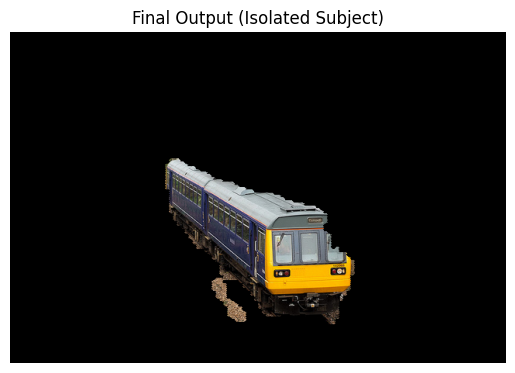

In [ ]:
output = image_np * mask_resized[:, :, None]

plt.imshow(output)
plt.title("Final Output (Isolated Subject)")
plt.axis("off")

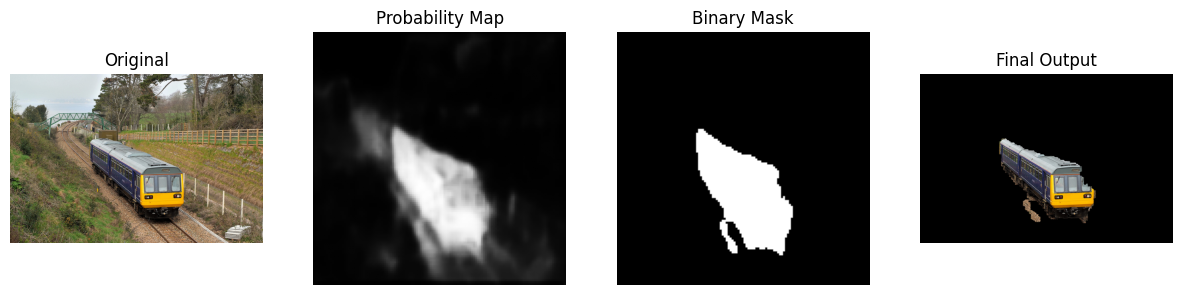

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.imshow(image_np)
plt.title("Original")

plt.subplot(1,4,2)
plt.imshow(pred, cmap='gray')
plt.title("Probability Map")

plt.subplot(1,4,3)
plt.imshow(binary_mask, cmap='gray')
plt.title("Binary Mask")

plt.subplot(1,4,4)
plt.imshow(output)
plt.title("Final Output")

for i in range(4):
    plt.subplot(1,4,i+1)
    plt.axis("off")

plt.show()